# Results Summary — Supervised vs SimCLR vs NCL
Teeno `sae_*.ipynb` notebooks chalane ke baad ye notebook run karo. `final_results_table.json` aur per-mode figures se ek clean comparison table, bar charts, aur combined qualitative figure banata hai -- seedha paper (Section 7) mein use karne ke liye.

**Pehle confirm karo teeno `sae_supervised.ipynb`, `sae_simclr.ipynb`, `sae_ncl.ipynb` complete ho chuki hain.**

## 1. Config + Load

In [1]:
import os, json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

RESULTS_ROOT = r"C:\Users\Raaghav\Desktop\coding\research\brain-mri-ncl-simclr\results"
MODES = ["supervised", "simclr", "ncl"]
MODE_LABELS = {"supervised": "Supervised", "simclr": "SimCLR", "ncl": "NCL (Ours)"}

final_table_path = os.path.join(RESULTS_ROOT, "final_results_table.json")
with open(final_table_path) as f:
    final_results = json.load(f)

missing = [m for m in MODES if m not in final_results]
if missing:
    print(f"WARNING: in modes ka data missing hai -- pehle unki sae_*.ipynb chalao: {missing}")
else:
    print("Sab teeno modes ka data mil gaya.")

print(json.dumps(final_results, indent=2))

Sab teeno modes ka data mil gaya.
{
  "supervised": {
    "sae_final_loss": 0.00013446955640877907,
    "n_alive_features": 59,
    "mean_purity": 0.8983050847457625,
    "mean_entropy": 0.20465238162755078,
    "downstream_probe_accuracy": 0.8609535811804243,
    "spatial_dice": 0.010655575355715884,
    "best_feature_idx": 35,
    "best_feature_purity": 1.0
  },
  "simclr": {
    "sae_final_loss": 0.0014782277106617887,
    "n_alive_features": 499,
    "mean_purity": 0.7955689156089959,
    "mean_entropy": 0.43874693704182394,
    "downstream_probe_accuracy": 0.8653644192396556,
    "spatial_dice": 0.2857142853061225,
    "best_feature_idx": 0,
    "best_feature_purity": 1.0
  },
  "ncl": {
    "sae_final_loss": 6.220397141684467e-05,
    "n_alive_features": 44,
    "mean_purity": 0.8431818181818184,
    "mean_entropy": 0.3294952119516055,
    "downstream_probe_accuracy": 0.8767065742491074,
    "spatial_dice": 0.17475506932574839,
    "best_feature_idx": 232,
    "best_feature_purit

## 2. Clean comparison table (paper-ready)

In [3]:
metric_rows = [
    ("Mean Purity \u2191", "mean_purity", "{:.3f}"),
    ("Mean Entropy \u2193", "mean_entropy", "{:.3f}"),
    ("Alive SAE Features", "n_alive_features", "{:d}"),
    ("Downstream Probe Accuracy", "downstream_probe_accuracy", "{:.3f}"),
    ("Spatial Dice (ablation)", "spatial_dice", "{:.3f}"),
    ("SAE Final Recon Loss", "sae_final_loss", "{:.4f}"),
]

table_data = {}
for label, key, fmt in metric_rows:
    row = {}
    for mode in MODES:
        if mode in final_results and key in final_results[mode]:
            val = final_results[mode][key]
            row[MODE_LABELS[mode]] = fmt.format(val) if val is not None else "N/A"
        else:
            row[MODE_LABELS[mode]] = "N/A"
    table_data[label] = row

df = pd.DataFrame(table_data).T
df = df[[MODE_LABELS[m] for m in MODES]]  # column order lock karo

print(df.to_string())

# Save karo -- CSV (Excel ke liye) + Markdown (paper/README ke liye)
csv_path = os.path.join(RESULTS_ROOT, "comparison_table.csv")
md_path = os.path.join(RESULTS_ROOT, "comparison_table.md")
df.to_csv(csv_path)
with open(md_path, "w", encoding="utf-8") as f:
    f.write(df.to_markdown())

print(f"\nSaved: {csv_path}")
print(f"Saved: {md_path}")
df

                          Supervised  SimCLR NCL (Ours)
Mean Purity ↑                  0.898   0.796      0.843
Mean Entropy ↓                 0.205   0.439      0.329
Alive SAE Features                59     499         44
Downstream Probe Accuracy      0.861   0.865      0.877
Spatial Dice (ablation)        0.011   0.286      0.175
SAE Final Recon Loss          0.0001  0.0015     0.0001

Saved: C:\Users\Raaghav\Desktop\coding\research\brain-mri-ncl-simclr\results\comparison_table.csv
Saved: C:\Users\Raaghav\Desktop\coding\research\brain-mri-ncl-simclr\results\comparison_table.md


,Supervised,SimCLR,NCL (Ours)
Mean Purity ↑,0.898,0.796,0.843
Mean Entropy ↓,0.205,0.439,0.329
Alive SAE Features,59,499,44
Downstream Probe Accuracy,0.861,0.865,0.877
Spatial Dice (ablation),0.011,0.286,0.175
SAE Final Recon Loss,0.0001,0.0015,0.0001


## 3. Bar charts — teeno metrics ka visual comparison

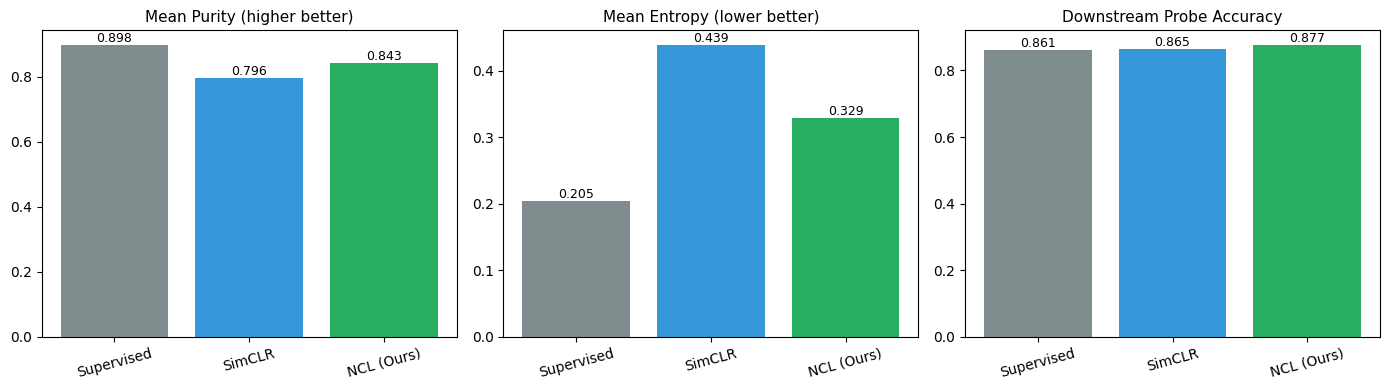

Saved: C:\Users\Raaghav\Desktop\coding\research\brain-mri-ncl-simclr\results\figures_comparison_bars.png


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
colors = ["#7f8c8d", "#3498db", "#27ae60"]  # supervised=grey, simclr=blue, ncl=green

chart_metrics = [
    ("mean_purity", "Mean Purity (higher better)", axes[0]),
    ("mean_entropy", "Mean Entropy (lower better)", axes[1]),
    ("downstream_probe_accuracy", "Downstream Probe Accuracy", axes[2]),
]

for key, title, ax in chart_metrics:
    values = [final_results[m].get(key, 0) for m in MODES]
    bars = ax.bar([MODE_LABELS[m] for m in MODES], values, color=colors)
    ax.set_title(title, fontsize=11)
    ax.tick_params(axis="x", rotation=15)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f"{val:.3f}",
                 ha="center", va="bottom", fontsize=9)

plt.tight_layout()
fig_path = os.path.join(RESULTS_ROOT, "figures_comparison_bars.png")
fig.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved: {fig_path}")

## 3b. Remaining metrics — individual bar charts
Bacha hua 3 metrics jo table mein hain par abhi tak chart nahi bane the: Alive SAE Features, Spatial Dice (ablation), aur SAE Final Reconstruction Loss. Ab total 4 bar charts ho jaayenge (1 combined + 3 individual).

In [ ]:
fig, ax = plt.subplots(figsize=(5, 4))
values = [final_results[m]["n_alive_features"] for m in MODES]
bars = ax.bar([MODE_LABELS[m] for m in MODES], values, color=colors)
ax.set_title("Alive SAE Features")
ax.bar_label(bars, fmt="%d")
plt.tight_layout()

alive_path = os.path.join(RESULTS_ROOT, "chart_alive_features.png")
fig.savefig(alive_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {alive_path}")

In [ ]:
fig, ax = plt.subplots(figsize=(5, 4))
values = [final_results[m]["spatial_dice"] for m in MODES]
bars = ax.bar([MODE_LABELS[m] for m in MODES], values, color=colors)
ax.set_title("Spatial Dice (ablation, higher better)")
ax.bar_label(bars, fmt="%.3f")
plt.tight_layout()

dice_path = os.path.join(RESULTS_ROOT, "chart_spatial_dice.png")
fig.savefig(dice_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {dice_path}")

In [ ]:
fig, ax = plt.subplots(figsize=(5, 4))
values = [final_results[m]["sae_final_loss"] for m in MODES]
bars = ax.bar([MODE_LABELS[m] for m in MODES], values, color=colors)
ax.set_title("SAE Final Reconstruction Loss (lower better)")
ax.set_yscale("log")
ax.bar_label(bars, fmt="%.5f")
plt.tight_layout()

loss_path = os.path.join(RESULTS_ROOT, "chart_sae_recon_loss.png")
fig.savefig(loss_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {loss_path}")

## 4. Combined qualitative figure — teeno backbones ke top-10 grids ek saath
Har mode ki `sae_*.ipynb` ne apna `top10_<mode>.png` already bana rakha hai (`results/<mode>/figures/`). Yahan sirf unhe stack kar rahe hain -- models dobara load nahi karne
padenge.

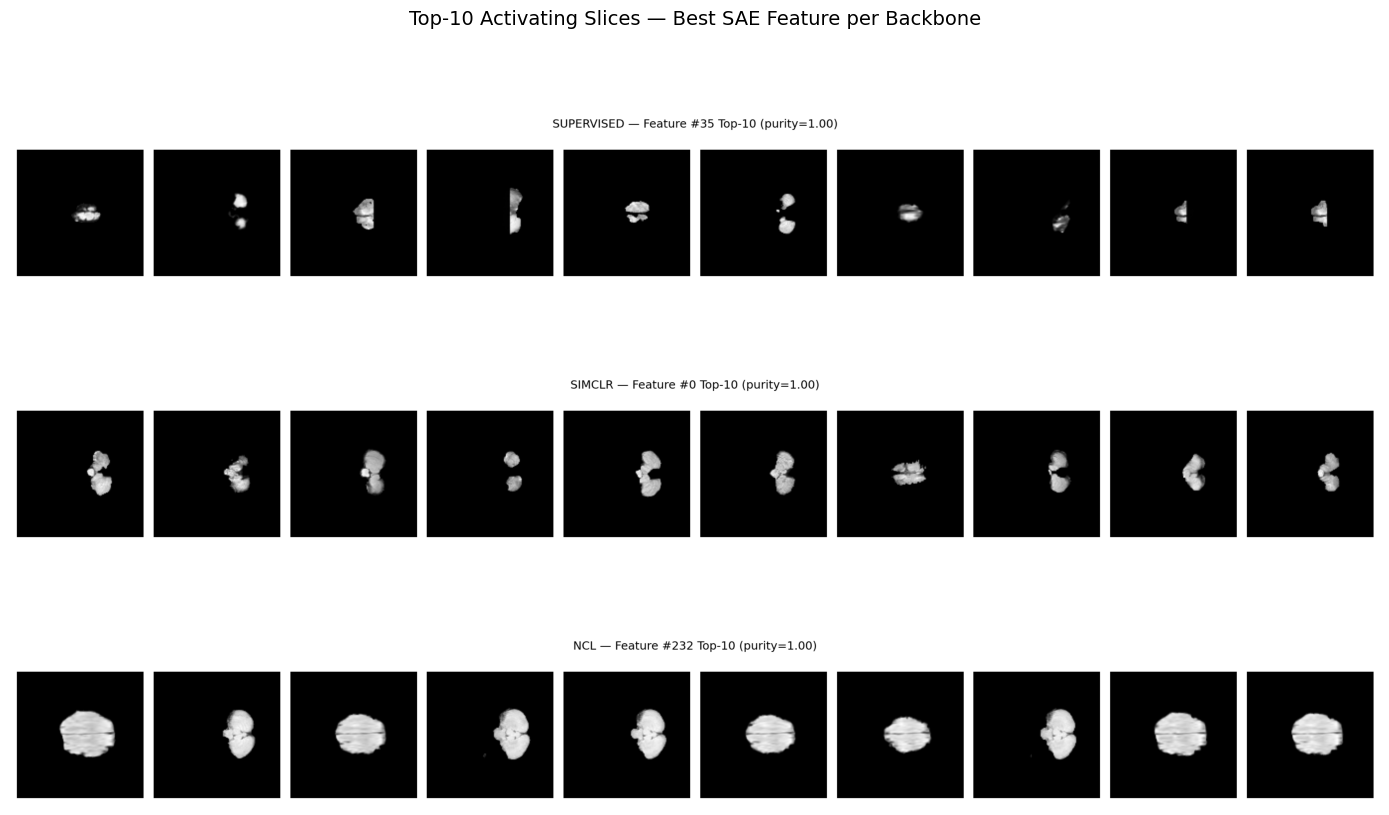

Saved: C:\Users\Raaghav\Desktop\coding\research\brain-mri-ncl-simclr\results\figures_top10_combined.png  <-- ye tumhare paper ka Section 7 key figure hai


In [5]:
fig, axes = plt.subplots(3, 1, figsize=(14, 9))

for i, mode in enumerate(MODES):
    img_path = os.path.join(RESULTS_ROOT, mode, "figures", f"top10_{mode}.png")
    if os.path.exists(img_path):
        img = mpimg.imread(img_path)
        axes[i].imshow(img)
    else:
        axes[i].text(0.5, 0.5, f"{mode}: figure missing", ha="center", va="center")
    axes[i].axis("off")

plt.suptitle("Top-10 Activating Slices — Best SAE Feature per Backbone", fontsize=14)
plt.tight_layout()

combined_path = os.path.join(RESULTS_ROOT, "figures_top10_combined.png")
fig.savefig(combined_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved: {combined_path}  <-- ye tumhare paper ka Section 7 key figure hai")

## 5. Hypothesis check -- quick summary print

In [6]:
sup, sim, ncl = final_results["supervised"], final_results["simclr"], final_results["ncl"]

print("=== Hypothesis Check: NCL vs SimCLR (core comparison -- dono self-supervised) ===")
print(f"Purity:  NCL {ncl['mean_purity']:.3f} vs SimCLR {sim['mean_purity']:.3f}  -> "
      f"{'NCL BETTER' if ncl['mean_purity'] > sim['mean_purity'] else 'SimCLR better'}")
print(f"Entropy: NCL {ncl['mean_entropy']:.3f} vs SimCLR {sim['mean_entropy']:.3f}  -> "
      f"{'NCL BETTER (lower)' if ncl['mean_entropy'] < sim['mean_entropy'] else 'SimCLR better'}")

print("\n=== NCL vs Supervised ===")
print(f"Purity:  NCL {ncl['mean_purity']:.3f} vs Supervised {sup['mean_purity']:.3f}  -> "
      f"{'NCL BETTER' if ncl['mean_purity'] > sup['mean_purity'] else 'Supervised better'}")
print(f"Entropy: NCL {ncl['mean_entropy']:.3f} vs Supervised {sup['mean_entropy']:.3f}  -> "
      f"{'NCL BETTER (lower)' if ncl['mean_entropy'] < sup['mean_entropy'] else 'Supervised better'}")

print("\n=== Downstream task performance (interpretability cost check) ===")
best_probe = max(MODES, key=lambda m: final_results[m]["downstream_probe_accuracy"])
print(f"Best probe accuracy: {MODE_LABELS[best_probe]} ({final_results[best_probe]['downstream_probe_accuracy']:.3f})")

print("\n=== Alive features (representation richness signal) ===")
for m in MODES:
    print(f"  {MODE_LABELS[m]}: {final_results[m]['n_alive_features']}")

=== Hypothesis Check: NCL vs SimCLR (core comparison -- dono self-supervised) ===
Purity:  NCL 0.843 vs SimCLR 0.796  -> NCL BETTER
Entropy: NCL 0.329 vs SimCLR 0.439  -> NCL BETTER (lower)

=== NCL vs Supervised ===
Purity:  NCL 0.843 vs Supervised 0.898  -> Supervised better
Entropy: NCL 0.329 vs Supervised 0.205  -> Supervised better

=== Downstream task performance (interpretability cost check) ===
Best probe accuracy: NCL (Ours) (0.877)

=== Alive features (representation richness signal) ===
  Supervised: 59
  SimCLR: 499
  NCL (Ours): 44
